In [315]:
from qiskit import QuantumCircuit

# Create a single-qubit circuit
qc = QuantumCircuit(1)

# Apply a Hadamard gate
qc.h(0)

# Draw the circuit
qc.draw()

┌───┐
q: ┤ H ├
   └───┘

In [316]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

# Apply an X gate
qc.x(0)

qc.draw("text")

┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────

In [317]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3,3) #how many qubits, how many classical bits held in register

qc.h(1)
qc.h(0)    #makes h gate on q_0
qc.x(2)    #makes x gate on q_2

#qc.measure_all() # measures all wires
qc.measure(1,2) # measures only q_1, how many classical bits are stored in register

print(qc.draw())

     ┌───┐   
q_0: ┤ H ├───
     ├───┤┌─┐
q_1: ┤ H ├┤M├
     ├───┤└╥┘
q_2: ┤ X ├─╫─
     └───┘ ║ 
c: 3/══════╩═
           2 


Qubit lives on **Bloch Sphere**
+ **note** "q:" from above is a qubit
+ top = |0> and bottom = |1>
+ in the case above, we have 3 qubits, having state 1/2(|100>+|101>+|110>+|111>) after applying all gates

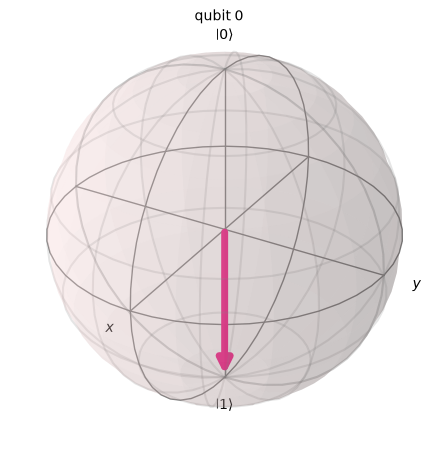

In [318]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)

qc.h(0)
qc.z(0)
qc.h(0)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

In [319]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
qc.h(0)

state = Statevector.from_instruction(qc)

print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


**Note**:
+ Bloch Sphere and Hilbert Space are two different things
+ For, example note this property |0> = [1 0]
+ |0> itself is plotted on bloch sphere
+ [1 0] is plotted in hilbert space
+ thus, the basis vectors for |0> and |1> are orthogonal in Hilbert space

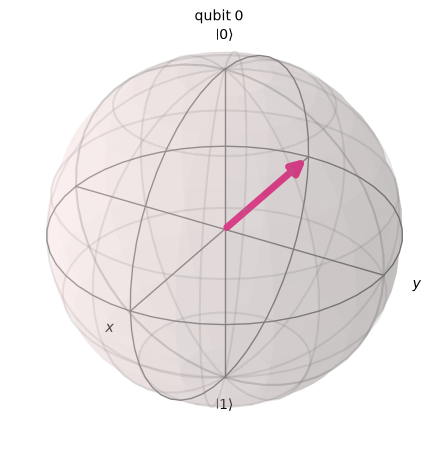

In [320]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)

qc.h(0)
qc.x(0)
qc.z(0)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

**We can use Y-Gates and Bloch Rotations**

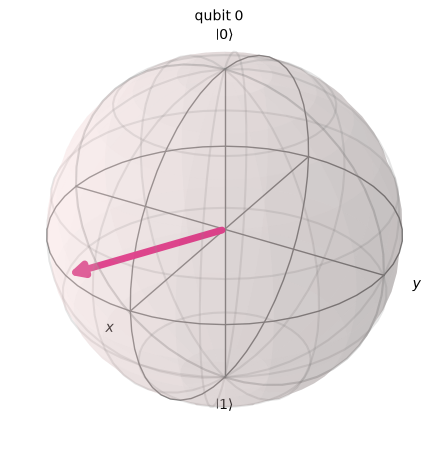

In [321]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(1)

qc.h(0)
qc.rz(pi/3,0)      # Change this line
qc.rz(pi/2,0)
qc.z(0)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

**Note**:
+ q0 = 1 and q1 = 0, thus |10>

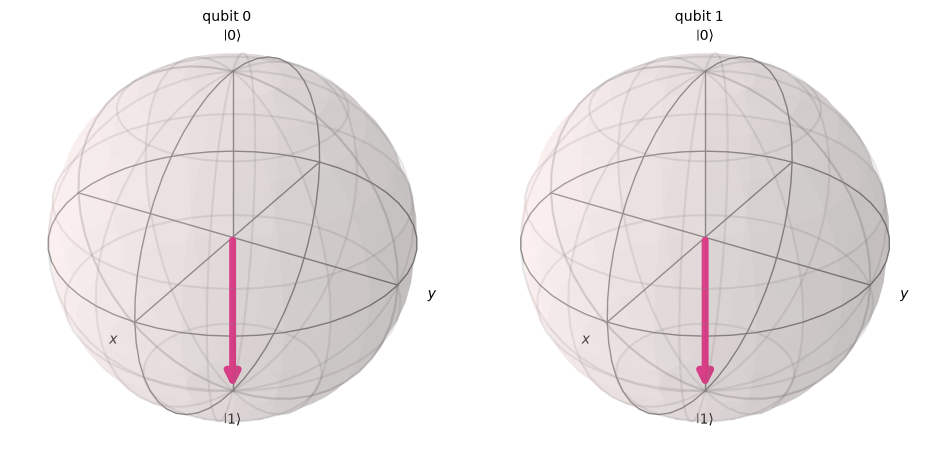

In [322]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(2)

qc.x(0)          # makes Statevector point DOWN
qc.cx(0,1)       # control=position with 0, target=position with 1. Rule: if control=1 on state, flip target
                 # here, target stays same since control = 0
                 # try flipping it to be 1, 0

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

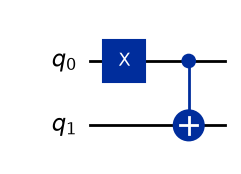

In [323]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.x(0)
qc.cx(0,1)

qc.draw("mpl")

**We now have state |11> (00-->10-->CNOT(0-control ,1-target)-->11)**
+ It's time for Bell State...

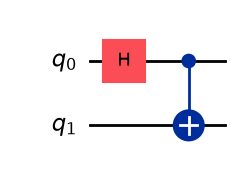

In [324]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0,1)

qc.draw("mpl")

In [325]:
# Find the state through finding its probability amplitudes!
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0,1)

state = Statevector.from_instruction(qc)

print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


**We now have a bell state** 
+ Case1: 00 --> |00>+|10> -->CNOT(1-target,0-control)-->|00>+|10>
+ Case2(IDEAL CNOT): 00 --> |00>+|10> -->CNOT(0-control,1-target)-->|00>+|11>

**Note something important**: Quantum teleportation NEEDS these three recources:
+ Unknown qubit/state (the information to transfer from Alice to Bob)
+ Entangled Bell pair (the quantum link)
+ Two classical bits (tell Bob which correction to apply)

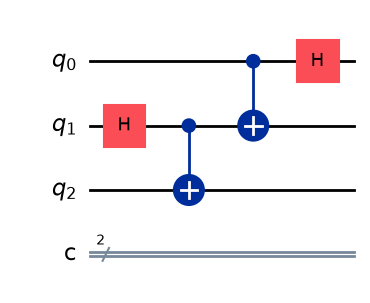

In [326]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 2) # three qubits and two classical bits stored

qc.h(1)
qc.cx(1, 2)
qc.cx(0,1)
qc.h(0)

qc.draw("mpl")

#Note:
#q0  ← Alice's unknown state (|ψ⟩)
#q1  ← Alice's half of the Bell pair
#q2  ← Bob's half of the Bell pair
#We entangle Alice and Bob first (Make the wire), then send the info in q0 thru that wire
# q0 = X-basis bit (+ or -) and q1 = Z-basis bit (0 or 1)
# Note: H then CNOT makes Bell pair/entanglement between q1 and q2
# And CNOT then H makes Bell-basis measurement on q0 and q1 (not to create another entanglement)

## Noise and Decoherence
Noise is broken into TWO types:
+ Decoherence: qubit does not stay exactly on the point we placed it on the Bloch Sphere (eventually, quantum info is lost)
+ Gate errors: qc.x(0) does not go full 180 degrees (~179.8 or ~180.3)

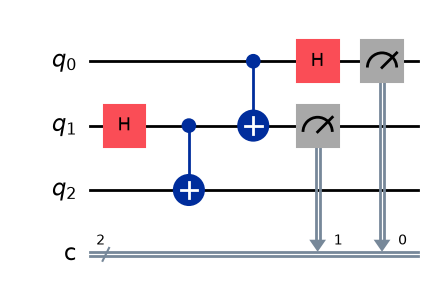

In [327]:
# Quantum teleportation! (but with measuring visualization)
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(3,2)

qc.h(1)
qc.cx(1,2)
qc.cx(0,1)
qc.h(0)

qc.measure(0,0) # which qubit measure, and how many CLASSICAL bits stored
qc.measure(1,1)
#qc.measure_all() # don't want this it messes up Bob's value, before he can decode it himself (with 2 classical bits

qc.draw("mpl")

# c: we store two CLASSICAL bits
# meas: the values we measured

## Congratulations! Now it's time to move to Quantum Algorithms
+ the **WHY** we use superposition and entanglement
+ Grover's algorithm includes flipping the phase and applying a diffusion operator to increase the probability amplitudes of different states (caveot: do it too many times and you drift away from right answer)

## Grover Search: 

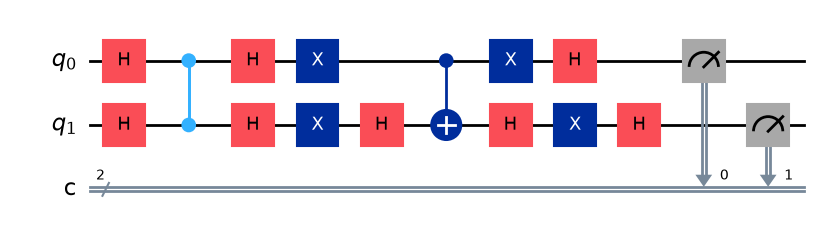

In [ ]:
# Lets say we had an array of 4 different fruit.
# One is the grape. 
# Lets find where it is. GROVER ALGORITHM
from qiskit import QuantumCircuit

qc = QuantumCircuit(2,2) # 2 qubits since 2^n=2^2 = 4 (possible answers)

qc.h([0,1]) # superposition AKA hamadard is on q0 and q1 branch (so looks at 4 possibilities at the same time)

qc.cz(0,1) # oracle marks correct answer: CZ gate is like CNOT but only changes the phase (|11> --> -|11>)

# Diffusion Operator (fourier transform but for quantum = increase the amplitude of marked state rather than find the different amplitudes for different frequencies)
qc.h([0,1])
qc.x([0,1])
qc.h(1)
qc.cx(0,1)
qc.h(1)
qc.x([0,1])
qc.h([0,1])

qc.measure([0,1],[0,1])
qc.draw("mpl")


#print("Qubits:", qc.num_qubits)
#print("Depth :", qc.depth())
#print("Size  :", qc.size())
#print("Ops   :", qc.count_ops())

## QFT = Phase Estimation time!

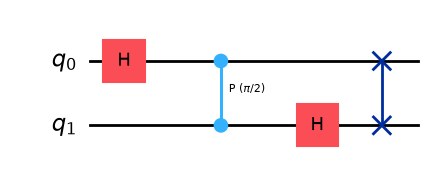

In [329]:
from math import pi
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cp(pi/2, 1, 0) # if qubit 1 is 1 then rotate qubit 0 by 90 degrees
qc.h(1) # phase differences --> interferences (narrow down)
qc.swap(0,1) # swap the qubits: QFT naturally reverses the order of output
qc.draw("mpl")

## Variational Parameters = using Ansatz (guess) then edit method

In [330]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np

# Adjustable parameter
theta = Parameter("θ")

# Build the ansatz (parameterized circuit)
qc = QuantumCircuit(1)
qc.ry(theta, 0)

print(qc)

   ┌───────┐
q: ┤ Ry(θ) ├
   └───────┘


In [331]:
angles = np.linspace(0, 2*np.pi, 9)

best_energy = float("inf")
best_angle = None

for angle in angles:
    state = Statevector.from_instruction(qc.assign_parameters({theta: angle}))

    # Fake energy function
    energy = state.expectation_value([[1,0],[0,-1]]).real

    print(f"θ = {angle:.2f}   Energy = {energy:.3f}")

    if energy < best_energy:
        best_energy = energy
        best_angle = angle

print("\nLowest energy found:")
print(f"θ = {best_angle:.2f}")
print(f"Energy = {best_energy:.3f}")

θ = 0.00   Energy = 1.000
θ = 0.79   Energy = 0.707
θ = 1.57   Energy = 0.000
θ = 2.36   Energy = -0.707
θ = 3.14   Energy = -1.000
θ = 3.93   Energy = -0.707
θ = 4.71   Energy = -0.000
θ = 5.50   Energy = 0.707
θ = 6.28   Energy = 1.000

Lowest energy found:
θ = 3.14
Energy = -1.000


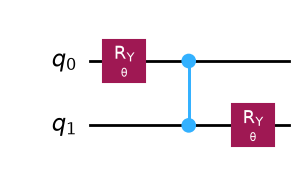

In [332]:
theta = Parameter("θ")

qc = QuantumCircuit(2)

qc.ry(theta,0)
qc.cz(0,1)
qc.ry(theta,1)
qc.draw("mpl")

## Shor's Algorithm

In [333]:
from math import gcd

# Number we want to factor
N = 15

# Choose a (must be coprime with N)
a = 2

print(f"Factoring N = {N}")
print(f"Chosen a = {a}\n")

# Step 1: Build the modular exponentiation table
print("f(x) = a^x mod N")

for x in range(8):
    print(f"x = {x:2d} -> {pow(a, x, N)}")

# Step 2: Pretend the quantum computer found the period
r = 4

print(f"\nQuantum computer found period r = {r}")

# Step 3: Classical post-processing
half_power = pow(a, r // 2)

factor1 = gcd(half_power - 1, N)
factor2 = gcd(half_power + 1, N)

print("\nFactors found:")
print(f"{factor1} × {factor2} = {N}")

Factoring N = 15
Chosen a = 2

f(x) = a^x mod N
x =  0 -> 1
x =  1 -> 2
x =  2 -> 4
x =  3 -> 8
x =  4 -> 1
x =  5 -> 2
x =  6 -> 4
x =  7 -> 8

Quantum computer found period r = 4

Factors found:
3 × 5 = 15


## It's time to create REUSABLE ALGORITHMS

In [334]:
# Simulating a Bell State / entanglement with reusable parameters
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Build the circuit
qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)

# Measure both qubits
qc.measure([0, 1], [0, 1])

# Create a simulator backend
backend = AerSimulator()

# Transpile the circuit for this backend = place to execute code (online simulator)
optimized = transpile(qc, backend)

# Run the circuit
job = backend.run(optimized, shots=1024)

# Get the results
result = job.result()
counts = result.get_counts()

print(counts)

{'00': 495, '11': 529}


Parameterized circuit:
   ┌───────┐┌───────┐
q: ┤ Ry(θ) ├┤ Rz(φ) ├
   └───────┘└───────┘

Circuit after assigning values:
   ┌─────────┐┌─────────┐
q: ┤ Ry(π/2) ├┤ Rz(π/4) ├
   └─────────┘└─────────┘


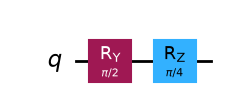

In [335]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# Create parameter objects (placeholders)
theta = Parameter("θ")
phi = Parameter("φ")

# Build a circuit
qc = QuantumCircuit(1)

# Use the parameters in the gates
qc.ry(theta, 0) # apply theta rotation, at qubit 0
qc.rz(phi, 0)

print("Parameterized circuit:")
print(qc)

# Assign actual values to the parameters
qc_bound = qc.assign_parameters({
    theta: pi/2,
    phi: pi/4
})

print("\nCircuit after assigning values:")
print(qc_bound)

# Draw the final circuit (optional)
qc_bound.draw("mpl")

## Toffoli gate (CCX - Multi Controlled Gates)

Here is the Truth Table (notice: it only changes when BOTH controls = 1)

Controls    Target Before   Target After

00               0              0
00               1              1

01               0              0
01               1              1

10               0              0
10               1              1

11               0              1
11               1              0

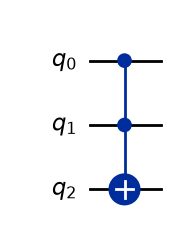

In [336]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)

qc.ccx(0, 1, 2)

qc.draw("mpl")

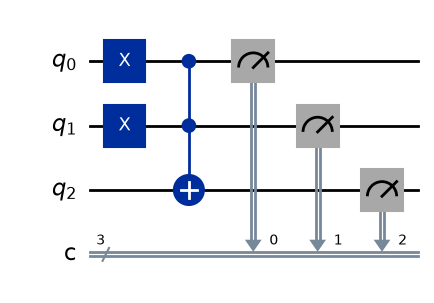

In [337]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 3)

# Prepare |110⟩
qc.x(0)
qc.x(1)

# Flip q2 only if q0 and q1 are both 1
qc.ccx(0, 1, 2)

qc.measure([0, 1, 2], [0, 1, 2])

qc.draw("mpl")

# Result is 111

## CCX (Toffoli gate) is NOT what we think!

Original:
          
q_0: ──■──
       │  
q_1: ──■──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘

Decomposed:
                                                       ┌───┐      
q_0: ───────────────────■─────────────────────■────■───┤ T ├───■──
                        │             ┌───┐   │  ┌─┴─┐┌┴───┴┐┌─┴─┐
q_1: ───────■───────────┼─────────■───┤ T ├───┼──┤ X ├┤ Tdg ├┤ X ├
     ┌───┐┌─┴─┐┌─────┐┌─┴─┐┌───┐┌─┴─┐┌┴───┴┐┌─┴─┐├───┤└┬───┬┘└───┘
q_2: ┤ H ├┤ X ├┤ Tdg ├┤ X ├┤ T ├┤ X ├┤ Tdg ├┤ X ├┤ T ├─┤ H ├──────
     └───┘└───┘└─────┘└───┘└───┘└───┘└─────┘└───┘└───┘ └───┘      


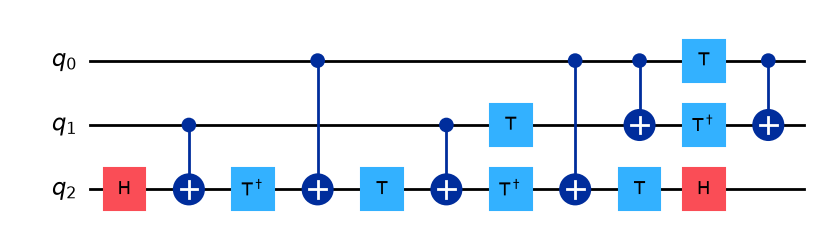

In [338]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)

qc.ccx(0, 1, 2)

print("Original:")
print(qc)

decomposed = qc.decompose()

print("\nDecomposed:")
print(decomposed)

decomposed.draw("mpl")

6
0


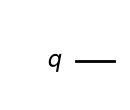

In [339]:
# Optimizing our circuit brought us from depth 6 (6 elements) to 0 depth (0 elements), to bring us to same result
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1)
backend = AerSimulator()

qc.x(0)
qc.x(0)

qc.h(0)
qc.h(0)

qc.z(0)
qc.z(0)

print(qc.depth())
qc.draw("mpl")

optimized = transpile(
    qc,
    backend,
    optimization_level=3
)

print(optimized.depth())

optimized.draw("mpl")

## For NISQ Computers, T1 (how long until state 'relaxes' or goes back to ground stateread for nex) and T2 (how long qubit loses its phase information)
+ Remember: phase drives interference, which lets us see correct answers

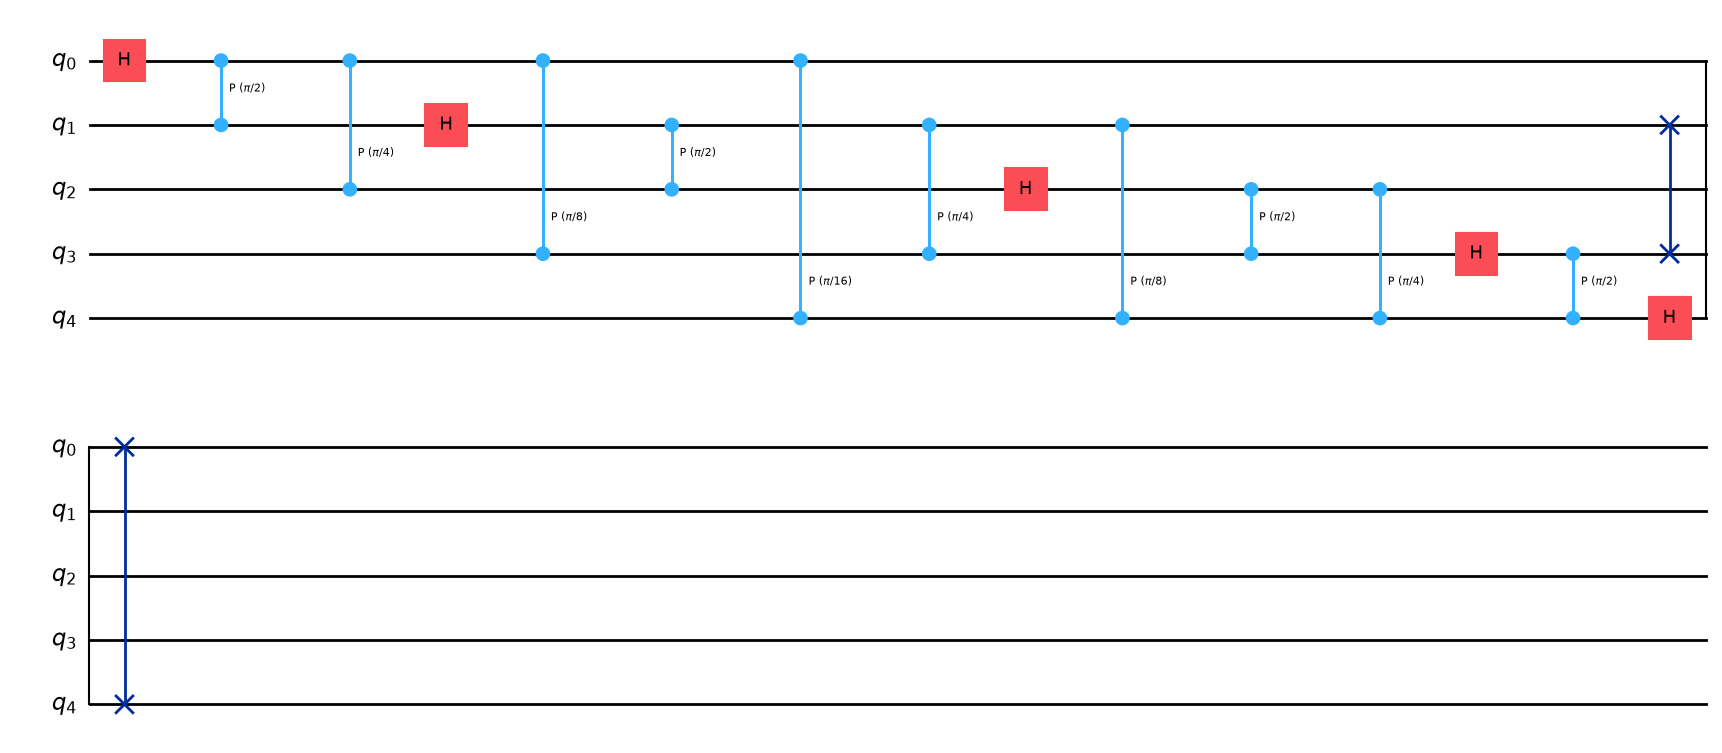

In [340]:
from math import pi
from qiskit import QuantumCircuit

def qft(qc, n):
    for target in range(n):

        qc.h(target)

        for control in range(target + 1, n):
            angle = pi / (2 ** (control - target))
            qc.cp(angle, control, target)

    for i in range(n // 2):
        qc.swap(i, n - 1 - i)

qc = QuantumCircuit(5)

qft(qc, 5)

qc.draw("mpl")
    

## Four numbers to ALWAYS CHECK:
+ print(qc.num_qubits)      # how many qubits do we deal with
+ print(qc.depth())         # how many one-to-one verticle layers
+ print(qc.size())          # how many operations (like H CX M,ect)
+ print(qc.count_ops())     # which gates and how many of each do we have